<a href="https://colab.research.google.com/github/gustavo159753/Analise-de-dados/blob/main/probabilidade_M%C3%A9d_Mediana_desv_pad_coef_assim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Média das notas: 79.61
Mediana das notas: 81.65
Desvio Padrão das notas: 11.78
Coeficiente de Assimetria: -0.68 (negativo indica cauda à esquerda)


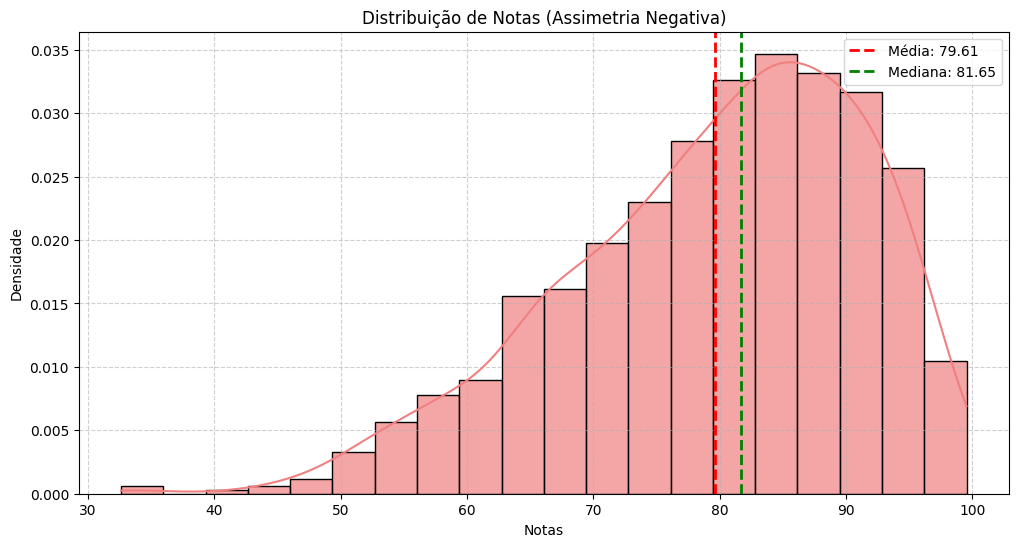

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

np.random.seed(42) # Para resultados repetíveis

# Gerar dados com assimetria negativa (usando uma distribuição beta)
# Invertemos e ajustamos a distribuição beta para simular assimetria negativa
notas = 100 - (np.random.beta(a=2, b=8, size=1000) * 100)

media_notas = np.mean(notas)
mediana_notas = np.median(notas)
desvio_padrao_notas = np.std(notas)
coef_assimetria_notas = skew(notas)

print(f"Média das notas: {media_notas:.2f}")
print(f"Mediana das notas: {mediana_notas:.2f}")
print(f"Desvio Padrão das notas: {desvio_padrao_notas:.2f}")
print(f"Coeficiente de Assimetria: {coef_assimetria_notas:.2f} (negativo indica cauda à esquerda)")

# Plotting
plt.figure(figsize=(12, 6))

# Histograma e Curva de Densidade
sns.histplot(notas, kde=True, color='lightcoral', stat='density', alpha=0.7)
plt.axvline(media_notas, color='red', linestyle='dashed', linewidth=2, label=f'Média: {media_notas:.2f}')
plt.axvline(mediana_notas, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_notas:.2f}')
plt.title('Distribuição de Notas (Assimetria Negativa)')
plt.xlabel('Notas')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Média dos salários: R$13,736.33
Mediana dos salários: R$9,224.55
Desvio Padrão dos salários: R$16,599.85
Coeficiente de Assimetria: 6.46 (positivo indica cauda à direita)


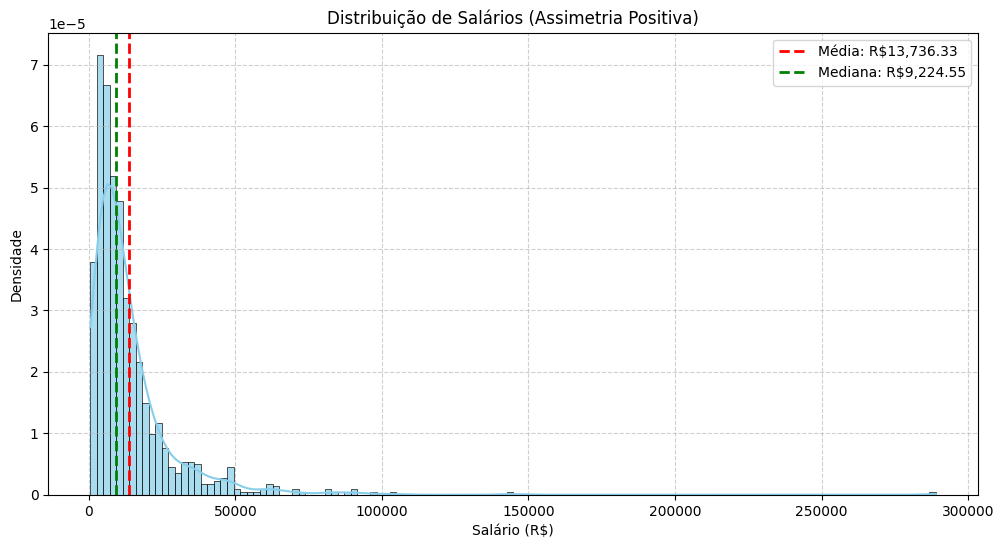

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

np.random.seed(42) # Para resultados repetíveis

# Gerar dados com assimetria positiva (usando uma distribuição lognormal)
salarios = np.random.lognormal(mean=9.8, sigma=0.9, size=1000)
salarios = salarios * 0.5 # Ajustar para valores mais realistas de salário

media_salarios = np.mean(salarios)
mediana_salarios = np.median(salarios)
desvio_padrao_salarios = np.std(salarios)
coef_assimetria_salarios = skew(salarios)

print(f"Média dos salários: R${media_salarios:,.2f}")
print(f"Mediana dos salários: R${mediana_salarios:,.2f}")
print(f"Desvio Padrão dos salários: R${desvio_padrao_salarios:,.2f}")
print(f"Coeficiente de Assimetria: {coef_assimetria_salarios:.2f} (positivo indica cauda à direita)")

# Plotting
plt.figure(figsize=(12, 6))

# Histograma e Curva de Densidade
sns.histplot(salarios, kde=True, color='skyblue', stat='density', alpha=0.7)
plt.axvline(media_salarios, color='red', linestyle='dashed', linewidth=2, label=f'Média: R${media_salarios:,.2f}')
plt.axvline(mediana_salarios, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: R${mediana_salarios:,.2f}')
plt.title('Distribuição de Salários (Assimetria Positiva)')
plt.xlabel('Salário (R$)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- Distribuição de Notas (Assimetria Negativa) com Polars ---
Média das notas: 80.00
Mediana das notas: 82.04
Desvio Padrão das notas: 12.06
Coeficiente de Assimetria: -0.83 (negativo indica cauda à esquerda)


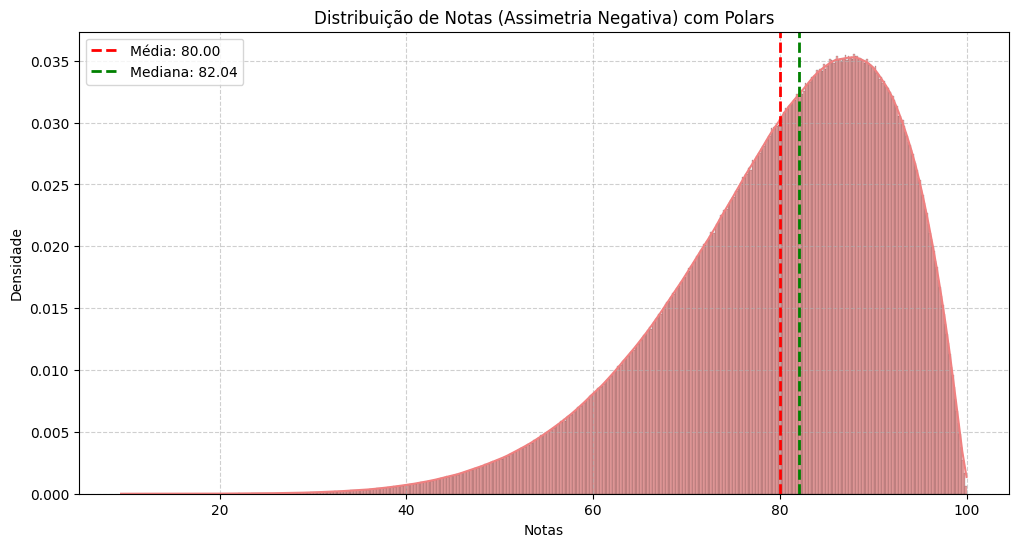


--- Distribuição de Salários (Assimetria Positiva) com Polars ---
Média dos salários: R$13,510.71
Mediana dos salários: R$9,014.73
Desvio Padrão dos salários: R$15,080.70
Coeficiente de Assimetria: 4.70 (positivo indica cauda à direita)


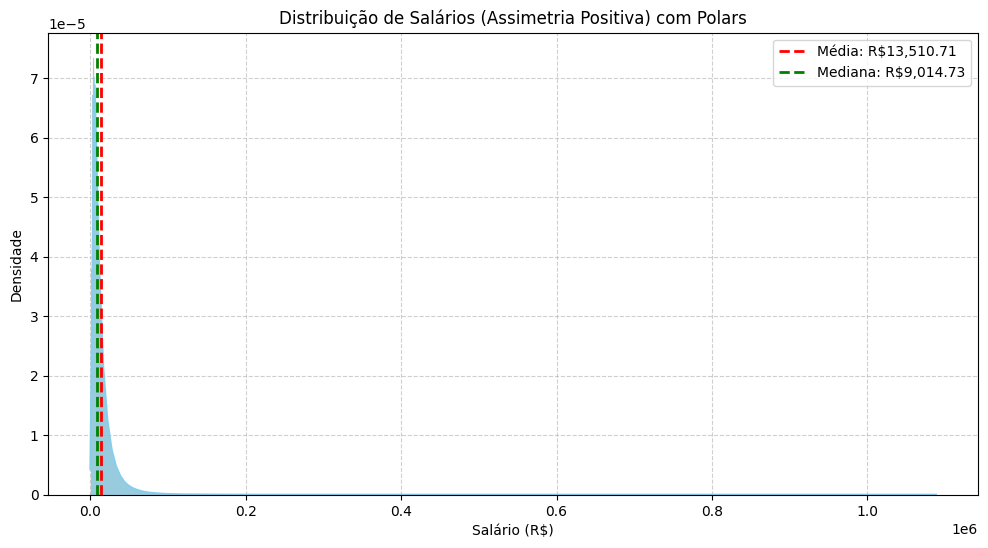

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew # Ainda usaremos para o cálculo da assimetria, já que o polars não tem nativamente um método skew com o mesmo tipo de cálculo da scipy

np.random.seed(42) # Para resultados repetíveis

print("--- Distribuição de Notas (Assimetria Negativa) com Polars ---")
# Gerar dados com assimetria negativa (usando uma distribuição beta)
# Invertemos e ajustamos a distribuição beta para simular assimetria negativa
notas_np = 100 - (np.random.beta(a=2, b=8, size=10000000) * 100)

# Converter para DataFrame Polars
df_notas = pl.DataFrame({"notas": notas_np})

# Calcular estatísticas com Polars
media_notas_pl = df_notas.select(pl.col("notas").mean()).item()
mediana_notas_pl = df_notas.select(pl.col("notas").median()).item()
desvio_padrao_notas_pl = df_notas.select(pl.col("notas").std()).item()
coef_assimetria_notas_pl = skew(df_notas["notas"].to_numpy()) # Usando scipy para consistência no cálculo da assimetria

print(f"Média das notas: {media_notas_pl:.2f}")
print(f"Mediana das notas: {mediana_notas_pl:.2f}")
print(f"Desvio Padrão das notas: {desvio_padrao_notas_pl:.2f}")
print(f"Coeficiente de Assimetria: {coef_assimetria_notas_pl:.2f} (negativo indica cauda à esquerda)")

# Plotting
plt.figure(figsize=(12, 6))

# Histograma e Curva de Densidade
sns.histplot(df_notas["notas"], kde=True, color='lightcoral', stat='density', alpha=0.7)
plt.axvline(media_notas_pl, color='red', linestyle='dashed', linewidth=2, label=f'Média: {media_notas_pl:.2f}')
plt.axvline(mediana_notas_pl, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_notas_pl:.2f}')
plt.title('Distribuição de Notas (Assimetria Negativa) com Polars')
plt.xlabel('Notas')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n--- Distribuição de Salários (Assimetria Positiva) com Polars ---")
# Gerar dados com assimetria positiva (usando uma distribuição lognormal)
salarios_np = np.random.lognormal(mean=9.8, sigma=0.9, size=10000000)
salarios_np = salarios_np * 0.5 # Ajustar para valores mais realistas de salário

# Converter para DataFrame Polars
df_salarios = pl.DataFrame({"salarios": salarios_np})

# Calcular estatísticas com Polars
media_salarios_pl = df_salarios.select(pl.col("salarios").mean()).item()
mediana_salarios_pl = df_salarios.select(pl.col("salarios").median()).item()
desvio_padrao_salarios_pl = df_salarios.select(pl.col("salarios").std()).item()
coef_assimetria_salarios_pl = skew(df_salarios["salarios"].to_numpy()) # Usando scipy para consistência no cálculo da assimetria

print(f"Média dos salários: R${media_salarios_pl:,.2f}")
print(f"Mediana dos salários: R${mediana_salarios_pl:,.2f}")
print(f"Desvio Padrão dos salários: R${desvio_padrao_salarios_pl:,.2f}")
print(f"Coeficiente de Assimetria: {coef_assimetria_salarios_pl:.2f} (positivo indica cauda à direita)")

# Plotting
plt.figure(figsize=(12, 6))

# Histograma e Curva de Densidade
sns.histplot(df_salarios["salarios"], kde=True, color='skyblue', stat='density', alpha=0.7)
plt.axvline(media_salarios_pl, color='red', linestyle='dashed', linewidth=2, label=f'Média: R${media_salarios_pl:,.2f}')
plt.axvline(mediana_salarios_pl, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: R${mediana_salarios_pl:,.2f}')
plt.title('Distribuição de Salários (Assimetria Positiva) com Polars')
plt.xlabel('Salário (R$)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
from google.colab import output
output.disable_custom_widget_manager()

In [ ]:
import numpy as np
import polars as pl
import holoviews as hv
import hvplot.polars  # noqa
import holoviews.operation.datashader as hvds
from scipy.stats import skew

hv.extension('bokeh')
print("HoloViews and hvplot.polars imported and initialized with Bokeh backend.")

np.random.seed(42) # Para resultados repetíveis

print("\n--- Distribuição de Notas (Assimetria Negativa) com Polars e HoloViews ---")
# Gerar dados com assimetria negativa (usando uma distribuição beta)
notas_np = 100 - (np.random.beta(a=2, b=8, size=10000000) * 100)
df_notas = pl.DataFrame({"notas": notas_np})

# Calcular estatísticas com Polars
media_notas_pl = df_notas.select(pl.col("notas").mean()).item()
mediana_notas_pl = df_notas.select(pl.col("notas").median()).item()
desvio_padrao_notas_pl = df_notas.select(pl.col("notas").std()).item()
coef_assimetria_notas_pl = skew(df_notas["notas"].to_numpy())

print(f"Média das notas: {media_notas_pl:.2f}")
print(f"Mediana das notas: {mediana_notas_pl:.2f}")
print(f"Desvio Padrão das notas: {desvio_padrao_notas_pl:.2f}")
print(f"Coeficiente de Assimetria: {coef_assimetria_notas_pl:.2f} (negativo indica cauda à esquerda)")

# Plotting Notas com HoloViews e Datashader
print("\n### Visualização da Distribuição de Notas (Assimetria Negativa) com HoloViews")
notas_hist_element = df_notas.hvplot.hist('notas',
                                          title='Distribuição de Notas (Assimetria Negativa) com HoloViews',
                                          xlabel='Notas', ylabel='Contagem', bins=50,
                                          height=400, width=600, legend=False)
notas_hist = hvds.rasterize(notas_hist_element)
mean_line_notas = hv.VLine(media_notas_pl, label=f'Média: {media_notas_pl:.2f}').opts(color='red', line_dash='dashed', line_width=2)
median_line_notas = hv.VLine(mediana_notas_pl, label=f'Mediana: {mediana_notas_pl:.2f}').opts(color='green', line_dash='dashed', line_width=2)
notas_plot = notas_hist * mean_line_notas * median_line_notas

# Display the plot (in a Colab environment, displaying the last HoloViews object renders it)
notas_plot

print("\n--- Distribuição de Salários (Assimetria Positiva) com Polars e HoloViews ---")
# Gerar dados com assimetria positiva (usando uma distribuição lognormal)
salarios_np = np.random.lognormal(mean=9.8, sigma=0.9, size=10000000)
salarios_np = salarios_np * 0.5
df_salarios = pl.DataFrame({"salarios": salarios_np})

# Calcular estatísticas com Polars
media_salarios_pl = df_salarios.select(pl.col("salarios").mean()).item()
mediana_salarios_pl = df_salarios.select(pl.col("salarios").median()).item()
desvio_padrao_salarios_pl = df_salarios.select(pl.col("salarios").std()).item()
coef_assimetria_salarios_pl = skew(df_salarios["salarios"].to_numpy())

print(f"Média dos salários: R${media_salarios_pl:,.2f}")
print(f"Mediana dos salários: R${mediana_salarios_pl:,.2f}")
print(f"Desvio Padrão dos salários: R${desvio_padrao_salarios_pl:,.2f}")
print(f"Coeficiente de Assimetria: {coef_assimetria_salarios_pl:.2f} (positivo indica cauda à direita)")

# Plotting Salários com HoloViews e Datashader
print("\n### Visualização da Distribuição de Salários (Assimetria Positiva) com HoloViews")
salarios_hist_element = df_salarios.hvplot.hist('salarios',
                                                title='Distribuição de Salários (Assimetria Positiva) com HoloViews',
                                                xlabel='Salário (R$)', ylabel='Contagem', bins=50,
                                                height=400, width=600, legend=False)
salarios_hist = hvds.rasterize(salarios_hist_element)
mean_line_salarios = hv.VLine(media_salarios_pl, label=f'Média: R${media_salarios_pl:,.2f}').opts(color='red', line_dash='dashed', line_width=2)
median_line_salarios = hv.VLine(mediana_salarios_pl, label=f'Mediana: R${mediana_salarios_pl:,.2f}').opts(color='green', line_dash='dashed', line_width=2)
salarios_plot = salarios_hist * mean_line_salarios * median_line_salarios

salarios_plot

HoloViews and hvplot.polars imported and initialized with Bokeh backend.

--- Distribuição de Notas (Assimetria Negativa) com Polars e HoloViews ---
Média das notas: 80.00
Mediana das notas: 82.04
Desvio Padrão das notas: 12.06
Coeficiente de Assimetria: -0.83 (negativo indica cauda à esquerda)

### Visualização da Distribuição de Notas (Assimetria Negativa) com HoloViews

--- Distribuição de Salários (Assimetria Positiva) com Polars e HoloViews ---
Média dos salários: R$13,510.71
Mediana dos salários: R$9,014.73
Desvio Padrão dos salários: R$15,080.70
Coeficiente de Assimetria: 4.70 (positivo indica cauda à direita)

### Visualização da Distribuição de Salários (Assimetria Positiva) com HoloViews


BokehModel(combine_events=True, render_bundle={'docs_json': {'f3a3e540-2494-4b3f-b48f-830d505343f5': {'version…

Support for third party widgets will remain active for the duration of the session. To disable support: